# analyze_experimental_data notebook
Interactive version of `analyze_experimental_data.py`.

- One plotting block per cell.
- Relevant variables are defined at the top of each plotting cell.
- Re-run the data-prep cell after changing settings in `analyze_experimental_data.py`.

In [13]:
from importlib import reload
import sys
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np

try:
    import Experimental_Data.analyze_experimental_data as analysis
except ModuleNotFoundError as exc:
    if getattr(exc, 'name', '') != 'Experimental_Data':
        raise
    current_dir = Path('Experimental_Data').resolve()
    if str(current_dir) not in sys.path:
        sys.path.insert(0, str(current_dir))
    import analyze_experimental_data as analysis

analysis = reload(analysis)

In [14]:
# Input sanity checks (run before Data prep)
RUN_SANITY_CHECKS = True
SANITY_SAMPLING_RTOL = 1e-3
SANITY_SAMPLING_ATOL = 1e-9
SANITY_MAX_PRINT_PER_COLUMN = 20


def _sampling_sanity(time_values, *, rtol, atol):
    t = np.asarray(time_values, dtype=float).reshape(-1)
    finite_mask = np.isfinite(t)
    time_nonfinite = int(np.count_nonzero(~finite_mask))
    t_finite = t[finite_mask]
    if t_finite.size < 2:
        return {
            'time_nonfinite': time_nonfinite,
            'monotonic_time': False,
            'constant_sampling': False,
            'dt_median': np.nan,
            'max_rel_dt_dev': np.nan,
        }

    diffs = np.diff(t_finite)
    monotonic_time = bool(np.all(diffs > 0.0))
    positive_diffs = diffs[(np.isfinite(diffs)) & (diffs > 0.0)]
    if positive_diffs.size == 0:
        return {
            'time_nonfinite': time_nonfinite,
            'monotonic_time': monotonic_time,
            'constant_sampling': False,
            'dt_median': np.nan,
            'max_rel_dt_dev': np.nan,
        }

    dt_median = float(np.median(positive_diffs))
    abs_dev = np.abs(positive_diffs - dt_median)
    rel_dev = abs_dev / max(abs(dt_median), 1e-15)
    return {
        'time_nonfinite': time_nonfinite,
        'monotonic_time': monotonic_time,
        'constant_sampling': bool(np.all(np.isclose(positive_diffs, dt_median, rtol=rtol, atol=atol))),
        'dt_median': dt_median,
        'max_rel_dt_dev': float(np.max(rel_dev)),
    }


def _column_label(col_idx, channel_names):
    if channel_names is not None and 0 <= int(col_idx) < len(channel_names):
        name = str(channel_names[int(col_idx)]).strip()
        if name:
            return f"col {int(col_idx)} ({name})"
    return f"col {int(col_idx)}"


def _nan_column_time_report(data, time_values, channel_names, *, max_items=20):
    arr = np.asarray(data, dtype=float)
    if arr.ndim != 2:
        return []

    t = np.asarray(time_values, dtype=float).reshape(-1)
    have_time = t.size == arr.shape[0]
    lines = []

    for col_idx in range(arr.shape[1]):
        col = np.asarray(arr[:, col_idx], dtype=float)
        nan_idx = np.flatnonzero(np.isnan(col))
        if nan_idx.size == 0:
            continue

        shown = nan_idx[: int(max_items)]
        samples = []
        for idx in shown:
            i = int(idx)
            if have_time:
                t_i = t[i]
                if np.isfinite(t_i):
                    samples.append(f"(i={i}, t={float(t_i):.6g})")
                else:
                    samples.append(f"(i={i}, t=nonfinite)")
            else:
                samples.append(f"(i={i})")

        extra = ""
        if nan_idx.size > int(max_items):
            extra = f" ... +{int(nan_idx.size - int(max_items))} more"

        lines.append(
            f"{_column_label(col_idx, channel_names)}: nan_count={int(nan_idx.size)} at "
            + ", ".join(samples)
            + extra
        )

    return lines


if RUN_SANITY_CHECKS:
    mat_files = analysis._resolve_mat_files()
    print(
        f"Sanity checks (sampling rtol={SANITY_SAMPLING_RTOL:g}, atol={SANITY_SAMPLING_ATOL:g})"
    )
    all_ok = True
    for mat_file in mat_files:
        try:
            data, channel_names = analysis._load_data_matrix(mat_file, analysis.DATA_VARIABLE)
        except Exception as exc:
            all_ok = False
            print(f"[FAIL] {mat_file.name}: could not load file ({exc})")
            continue

        total_count = int(data.size)
        matrix_nonfinite = int(total_count - np.count_nonzero(np.isfinite(data)))
        time_raw = analysis._select_column(data, channel_names, ['time', 'Time'], 0, role='sanity-check time')
        sampling = _sampling_sanity(
            time_raw,
            rtol=float(SANITY_SAMPLING_RTOL),
            atol=float(SANITY_SAMPLING_ATOL),
        )

        ok = (
            matrix_nonfinite == 0
            and int(sampling['time_nonfinite']) == 0
            and bool(sampling['monotonic_time'])
            and bool(sampling['constant_sampling'])
        )
        status = 'OK' if ok else 'WARN'
        if not ok:
            all_ok = False

        dt_median = sampling['dt_median']
        max_rel_dt_dev = sampling['max_rel_dt_dev']
        dt_txt = f"{dt_median:.9g}" if np.isfinite(dt_median) else 'n/a'
        max_rel_txt = f"{max_rel_dt_dev:.3e}" if np.isfinite(max_rel_dt_dev) else 'n/a'
        print(
            f"[{status}] {mat_file.name}: matrix_nonfinite={matrix_nonfinite}/{total_count}, "
            f"time_nonfinite={int(sampling['time_nonfinite'])}, "
            f"monotonic_time={bool(sampling['monotonic_time'])}, "
            f"constant_sampling={bool(sampling['constant_sampling'])}, "
            f"dt_median={dt_txt}, max_rel_dt_dev={max_rel_txt}"
        )

        nan_lines = _nan_column_time_report(
            data,
            time_raw,
            channel_names,
            max_items=int(SANITY_MAX_PRINT_PER_COLUMN),
        )
        if nan_lines:
            print(f"  NaN details (showing up to {int(SANITY_MAX_PRINT_PER_COLUMN)} rows per column):")
            for line in nan_lines:
                print(f"    {line}")

    if all_ok:
        print('Sanity checks passed for all selected files.')
    else:
        print('Sanity checks found issues in one or more files. Continuing.')



Sanity checks (sampling rtol=0.001, atol=1e-09)
[OK] test3003.mat: matrix_nonfinite=0/5806718, time_nonfinite=0, monotonic_time=True, constant_sampling=True, dt_median=0.005, max_rel_dt_dev=2.274e-11
[OK] test3004.mat: matrix_nonfinite=0/8690734, time_nonfinite=0, monotonic_time=True, constant_sampling=True, dt_median=0.005, max_rel_dt_dev=2.274e-11
[OK] test3005.mat: matrix_nonfinite=0/7081470, time_nonfinite=0, monotonic_time=True, constant_sampling=True, dt_median=0.005, max_rel_dt_dev=2.274e-11
[OK] test3006.mat: matrix_nonfinite=0/11953192, time_nonfinite=0, monotonic_time=True, constant_sampling=True, dt_median=0.005, max_rel_dt_dev=2.274e-11
[OK] test3008.mat: matrix_nonfinite=0/6033636, time_nonfinite=0, monotonic_time=True, constant_sampling=True, dt_median=0.005, max_rel_dt_dev=2.274e-11
[OK] test3010_part1.mat: matrix_nonfinite=0/5616500, time_nonfinite=0, monotonic_time=True, constant_sampling=True, dt_median=0.005, max_rel_dt_dev=2.274e-11
[OK] test3010_part2.mat: matrix_n

In [15]:
# Data prep
PRINT_SUMMARY = True
mat_files = analysis._resolve_mat_files()
entries = [analysis._process_file(p) for p in mat_files]
colors = plt.cm.tab10(np.linspace(0.0, 1.0, max(len(entries), 2)))
n_rows = len(entries)

if PRINT_SUMMARY:
    for entry in entries:
        s = entry['summary']
        print(
            f"{entry['label']}: Umean={s['umean']:.6f} m/s, Ur={s['ur']:.6f}, "
            f"Cd={s['cd']:.6f}, Ydomfreq={s['ydomfreq']:.6f} +/- {s['ydomfreq_std']:.6f} Hz, "
            f"nt={s['nt']}, dt={s['dt']:.6f} s, Fs={s['fs']:.6f} Hz, "
            f"coeff_norm={s['coeff_norm_mode']}"
        )
        if analysis.REMOVE_INERTIA_FROM_CF:
            print(
                f"{entry['label']}: applied inertia removal with "
                f"m_remove={s['m_inertia_removed']:.6f} kg "
                f"(M={analysis.M:.6f} kg, m_a={s['m_added']:.6f} kg, "
                f"include_m_a={analysis.INERTIA_INCLUDE_ADDED_MASS})"
            )

print(f'Loaded {len(entries)} entries from {len(mat_files)} file(s).')

test3003: Umean=0.328361 m/s, Ur=2.934414, Cd=1.307223, Ydomfreq=0.616321 +/- 0.116284 Hz, nt=126233, dt=0.005000 s, Fs=200.000000 Hz, coeff_norm=mean_u_plus_dy2
test3003: applied inertia removal with m_remove=16.790000 kg (M=16.790000 kg, m_a=8.050331 kg, include_m_a=False)
test3004: Umean=0.455822 m/s, Ur=4.073474, Cd=1.780194, Ydomfreq=0.771718 +/- 0.076332 Hz, nt=188929, dt=0.005000 s, Fs=200.000000 Hz, coeff_norm=mean_u_plus_dy2
test3004: applied inertia removal with m_remove=16.790000 kg (M=16.790000 kg, m_a=8.050331 kg, include_m_a=False)
test3005: Umean=0.647159 m/s, Ur=5.783371, Cd=2.418696, Ydomfreq=1.135470 +/- 0.050744 Hz, nt=153945, dt=0.005000 s, Fs=200.000000 Hz, coeff_norm=mean_u_plus_dy2
test3005: applied inertia removal with m_remove=16.790000 kg (M=16.790000 kg, m_a=8.050331 kg, include_m_a=False)
test3006: Umean=0.857951 m/s, Ur=7.667119, Cd=2.154798, Ydomfreq=1.588597 +/- 0.127398 Hz, nt=259852, dt=0.005000 s, Fs=200.000000 Hz, coeff_norm=mean_u_plus_dy2
test3006: 

## Simple Force Builder
Define one or more force models here.

Each model uses:
- `fy1_mult`, `fy2_mult` on spring components
- optional inertia from `M` and/or `m_a`
- `global_sign` on the full expression

The selected `ACTIVE_FORCE_MODEL` is injected into `entry['cfy']`, so all existing figure cells use it automatically.

In [16]:
# Simple force-generation block (edit this)
USE_CUSTOM_FORCE_MODELS = True

FORCE_MODELS = [
    {
        "name": "Spring Force",
        "fy1_mult": -1.0,
        "fy2_mult": +1.0,
        "global_sign": 1.0,
        "include_structural_mass": False,
        "include_added_mass": False,
        "inertia_sign": +1.0,
    },
    {
        "name": "Spring and Inertia",
        "fy1_mult": -1.0,
        "fy2_mult": +1.0,
        "global_sign": 1.0,
        "include_structural_mass": True,
        "include_added_mass": False,
        "inertia_sign": +1.0,
    },
    {
        "name": "Spring, Inertia(+Ma)",
        "fy1_mult": -1.0,
        "fy2_mult": +1.0,
        "global_sign": 1.0,
        "include_structural_mass": True,
        "include_added_mass": True,
        "inertia_sign": +1.0,
    },
]

ACTIVE_FORCE_MODEL = "Spring, Inertia(+Ma)"
# Empty list => plot all models in the overlay block.
PLOT_FORCE_MODELS = []
FORCE_LINESTYLES = ["-", "--", "-.", ":"]


def _normalize_models(models):
    out = []
    for i, m in enumerate(models):
        name = str(m.get("name", f"force_{i+1}")).strip() or f"force_{i+1}"
        out.append({
            "name": name,
            "fy1_mult": float(m.get("fy1_mult", 0.0)),
            "fy2_mult": float(m.get("fy2_mult", 0.0)),
            "global_sign": float(m.get("global_sign", 1.0)),
            "include_structural_mass": bool(m.get("include_structural_mass", False)),
            "include_added_mass": bool(m.get("include_added_mass", False)),
            "inertia_sign": float(m.get("inertia_sign", 1.0)),
        })
    names = [m["name"] for m in out]
    if len(set(names)) != len(names):
        raise ValueError("FORCE_MODELS must have unique names.")
    return out


if USE_CUSTOM_FORCE_MODELS:
    models = _normalize_models(FORCE_MODELS)
    model_names = [m["name"] for m in models]
    if ACTIVE_FORCE_MODEL not in model_names:
        raise ValueError(f"ACTIVE_FORCE_MODEL='{ACTIVE_FORCE_MODEL}' not in {model_names}")
    plot_names = model_names if not PLOT_FORCE_MODELS else [str(v) for v in PLOT_FORCE_MODELS]
    unknown = [v for v in plot_names if v not in model_names]
    if unknown:
        raise ValueError(f"Unknown model(s) in PLOT_FORCE_MODELS: {unknown}")

    m_added = float(analysis.ADDED_MASS_COEFF) * 0.25 * np.pi * analysis.RUO * analysis.D * analysis.D * analysis.L

    def _ensure_force_components(entry: dict) -> dict:
        needed = ("fy1_component", "fy2_component", "q_ref_vec")
        if all(k in entry for k in needed):
            return entry
        refreshed = analysis._process_file(Path(entry["path"]))
        entry.clear()
        entry.update(refreshed)
        return entry

    for entry in entries:
        entry = _ensure_force_components(entry)
        fy1 = np.asarray(entry["fy1_component"], dtype=float)
        fy2 = np.asarray(entry["fy2_component"], dtype=float)
        yacc = np.asarray(entry["yacc"], dtype=float)
        q_ref_vec = np.asarray(entry["q_ref_vec"], dtype=float)

        cfy_models = {}
        cfy_force_models = {}
        for model in models:
            m_inertia = 0.0
            if model["include_structural_mass"]:
                m_inertia += float(analysis.M)
            if model["include_added_mass"]:
                m_inertia += float(m_added)

            f_model = model["global_sign"] * (
                model["fy1_mult"] * fy1
                + model["fy2_mult"] * fy2
                + model["inertia_sign"] * m_inertia * yacc
            )
            cfy_force_models[model["name"]] = np.asarray(f_model, dtype=float)
            if analysis._use_raw_force_signals():
                cfy_models[model["name"]] = np.asarray(f_model, dtype=float)
            else:
                cfy_models[model["name"]] = np.asarray(f_model, dtype=float) / q_ref_vec

        entry["cfy_models"] = cfy_models
        entry["cfy_force_models"] = cfy_force_models
        entry["cfy_model_names"] = model_names
        entry["cfy_model_plot_names"] = plot_names
        entry["cfy_model_active"] = ACTIVE_FORCE_MODEL

        # Inject active model into standard fields so existing figure cells use it.
        entry["cfy"] = np.asarray(cfy_models[ACTIVE_FORCE_MODEL], dtype=float)
        entry["cfy_force"] = np.asarray(cfy_force_models[ACTIVE_FORCE_MODEL], dtype=float)

        fs = float(entry["summary"]["fs"])
        spc_cfy, f_cfy, n_cfy = analysis._spec(entry["cfy"], fs)
        if analysis.NORMALIZE_SPECTRA:
            spc_cfy = analysis._normalize_spectrum(spc_cfy, eps=analysis.SPECTRUM_NORM_EPS)
        entry["sp_cfy"] = (f_cfy, spc_cfy, n_cfy)

        y_nd = np.asarray(entry["y_nd"], dtype=float)
        ydomfreq = float(entry["summary"]["ydomfreq"])
        phase_cfy_by_model = {}
        for model_name, cfy_model in cfy_models.items():
            phase_cfy_by_model[model_name] = float(
                analysis._phase_lag_deg_at_frequency(
                    y_nd,
                    np.asarray(cfy_model, dtype=float),
                    fs=fs,
                    target_hz=ydomfreq,
                )
            )
        entry["phase_cfy_by_model_deg"] = phase_cfy_by_model
        entry["summary"]["phase_cfy_models_deg"] = dict(phase_cfy_by_model)
        entry["summary"]["phase_cfy_y_deg"] = float(phase_cfy_by_model[ACTIVE_FORCE_MODEL])

    print("Custom force models applied:", model_names)
    print("Active model:", ACTIVE_FORCE_MODEL)
else:
    for entry in entries:
        entry.setdefault("cfy_models", {"default": np.asarray(entry["cfy"], dtype=float)})
        entry.setdefault("cfy_force_models", {"default": np.asarray(entry["cfy_force"], dtype=float)})
        entry.setdefault("cfy_model_names", ["default"])
        entry.setdefault("cfy_model_plot_names", ["default"])
        entry.setdefault("cfy_model_active", "default")
        default_phase = float(entry["summary"].get("phase_cfy_y_deg", np.nan))
        entry.setdefault("phase_cfy_by_model_deg", {"default": default_phase})
        entry["summary"].setdefault("phase_cfy_models_deg", {"default": default_phase})


Custom force models applied: ['Spring Force', 'Spring and Inertia', 'Spring, Inertia(+Ma)']
Active model: Spring, Inertia(+Ma)


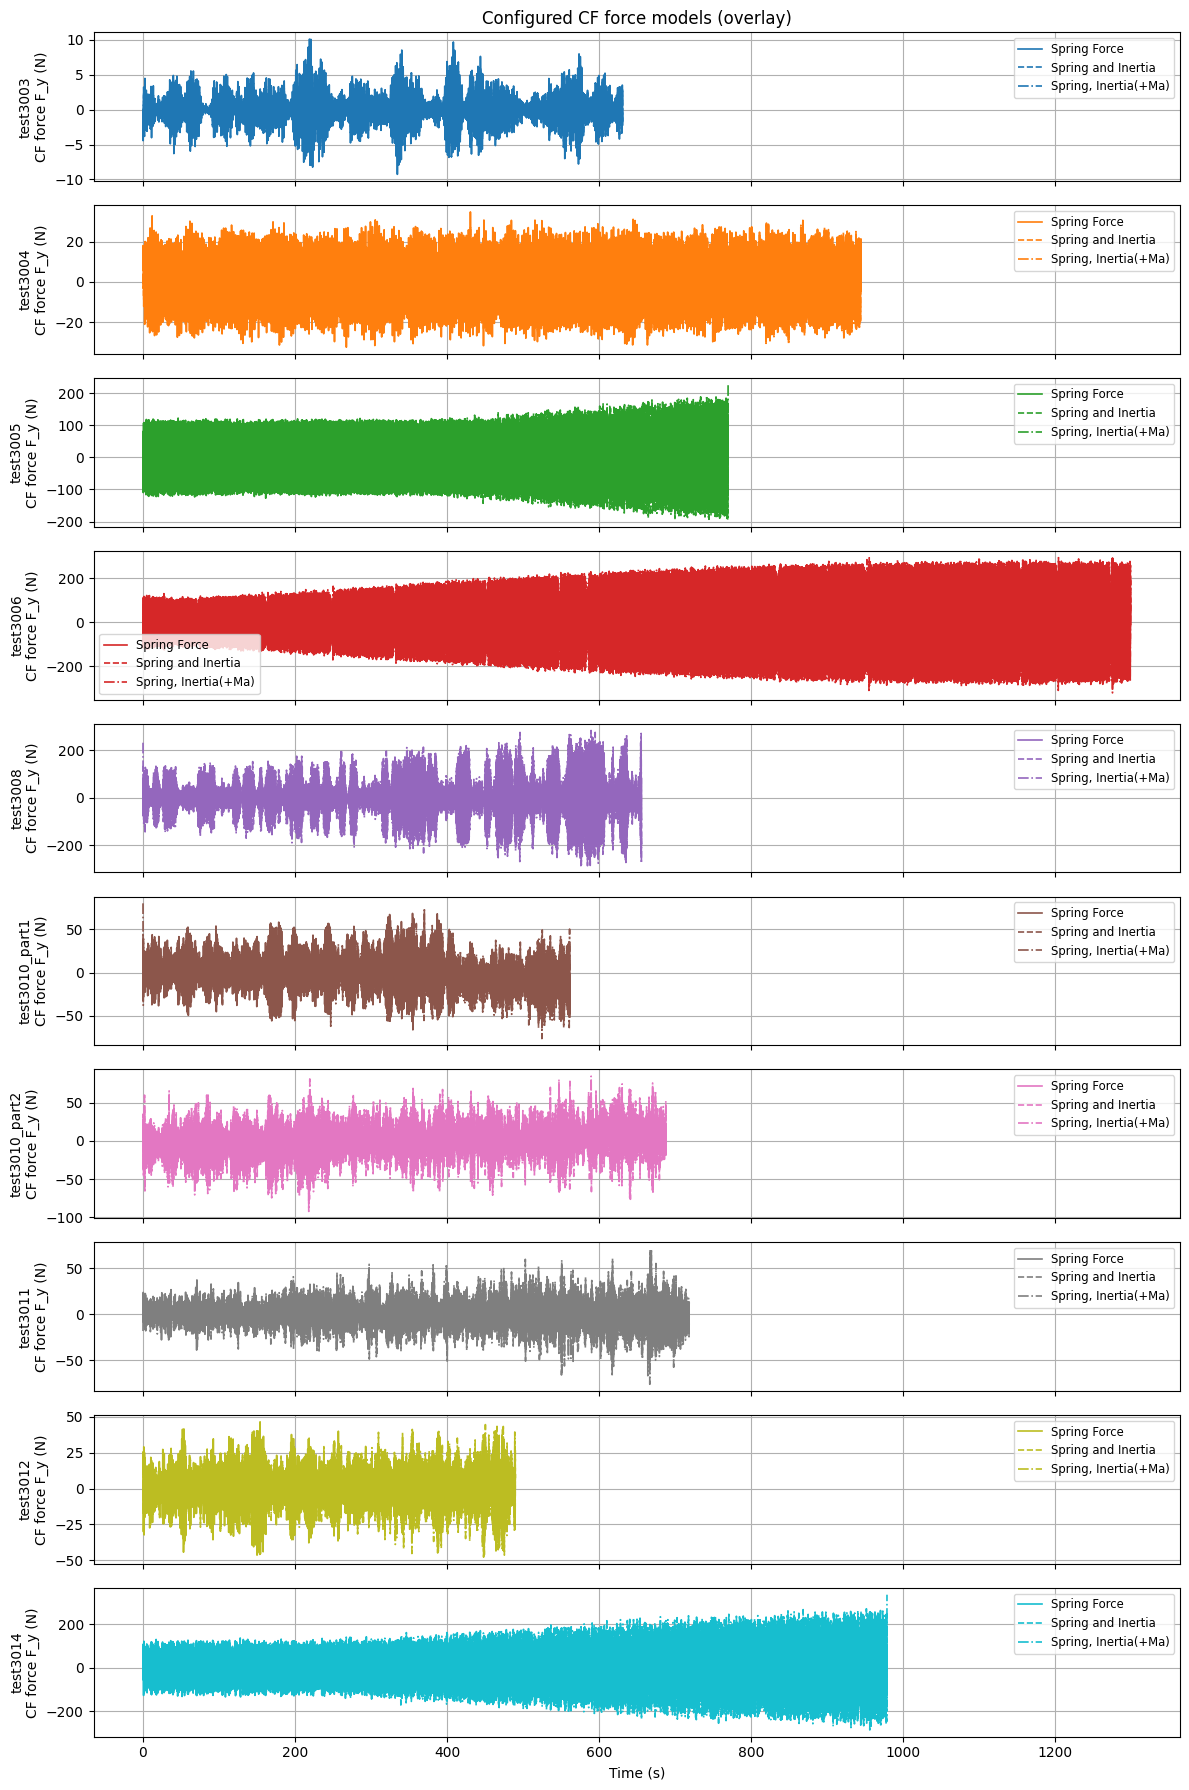

In [17]:
# Custom force-model overlay (all selected models together)
FORCE_OVERLAY_WIDTH = 12
FORCE_OVERLAY_ROW_HEIGHT = 1.8
FORCE_OVERLAY_MIN_HEIGHT = 3.0

fig_force, axes_force = plt.subplots(
    n_rows,
    1,
    figsize=(FORCE_OVERLAY_WIDTH, max(FORCE_OVERLAY_ROW_HEIGHT * n_rows, FORCE_OVERLAY_MIN_HEIGHT)),
    sharex=True,
)
axes_force = np.atleast_1d(axes_force)

for i, entry in enumerate(entries):
    ax = axes_force[i]
    base_color = colors[i % len(colors)]
    label = str(entry["label"])
    t = np.asarray(entry["time_plot"], dtype=float)
    plot_names = list(entry.get("cfy_model_plot_names", entry.get("cfy_model_names", [])))
    cfy_models = entry.get("cfy_models", {})

    for j, name in enumerate(plot_names):
        if name not in cfy_models:
            continue
        ls = FORCE_LINESTYLES[j % len(FORCE_LINESTYLES)]
        ax.plot(t, np.asarray(cfy_models[name], dtype=float), color=base_color, linestyle=ls, linewidth=1.2, label=name)

    ax.grid(True)
    ax.set_ylabel(f"{label}\n{analysis._cf_label()}")
    if len(plot_names) > 1:
        ax.legend(loc="best", fontsize="small")

axes_force[0].set_title("Configured CF force models (overlay)")
axes_force[-1].set_xlabel("Time (s)")
fig_force.tight_layout()
plt.show()


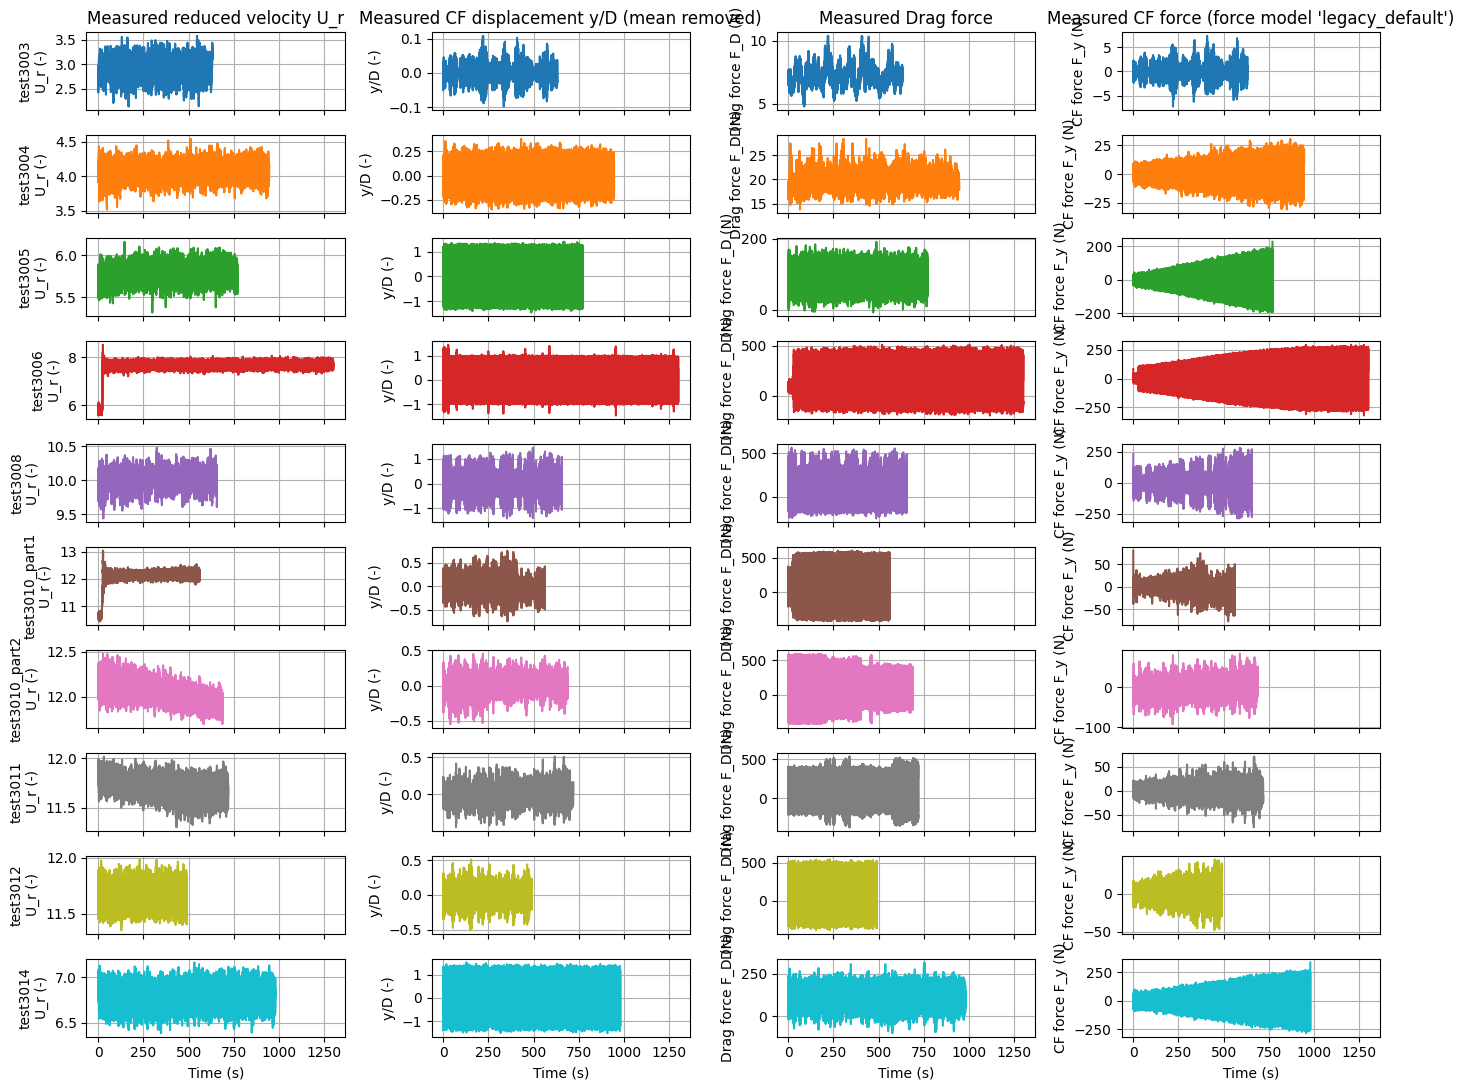

In [18]:
# Figure 1: full timeseries
FIG1_WIDTH = 14
FIG1_ROW_HEIGHT = 1.1
FIG1_MIN_HEIGHT = 2.0

fig1, axes1 = plt.subplots(
    n_rows,
    4,
    figsize=(FIG1_WIDTH, max(FIG1_ROW_HEIGHT * n_rows, FIG1_MIN_HEIGHT)),
    sharex='col',
)
axes1 = np.atleast_2d(axes1)
col_titles_full = [
    'Measured reduced velocity U_r',
    'Measured CF displacement y/D (mean removed)',
    f"Measured {analysis._drag_name()}",
    f"Measured {analysis._cf_name()} ({analysis._cf_force_mode_label()})",
]
for j, title in enumerate(col_titles_full):
    axes1[0, j].set_title(title)

for i, entry in enumerate(entries):
    color = colors[i % len(colors)]
    label = str(entry['label'])
    t = np.asarray(entry['time_plot'])
    ax_ur, ax_y, ax_cd, ax_cf = axes1[i, 0], axes1[i, 1], axes1[i, 2], axes1[i, 3]
    ax_ur.plot(t, np.asarray(entry['ur_inst']), color=color)
    ax_y.plot(t, np.asarray(entry['y_nd']), color=color)
    ax_cd.plot(t, np.asarray(entry['cdrag']), color=color)
    ax_cf.plot(t, np.asarray(entry['cfy']), color=color)
    for ax in (ax_ur, ax_y, ax_cd, ax_cf):
        ax.grid(True)
    ax_ur.set_ylabel(f"{label}\nU_r (-)")
    ax_y.set_ylabel('y/D (-)')
    ax_cd.set_ylabel(analysis._drag_label())
    ax_cf.set_ylabel(analysis._cf_label())

for j in range(4):
    axes1[-1, j].set_xlabel('Time (s)')
fig1.tight_layout()
plt.show()

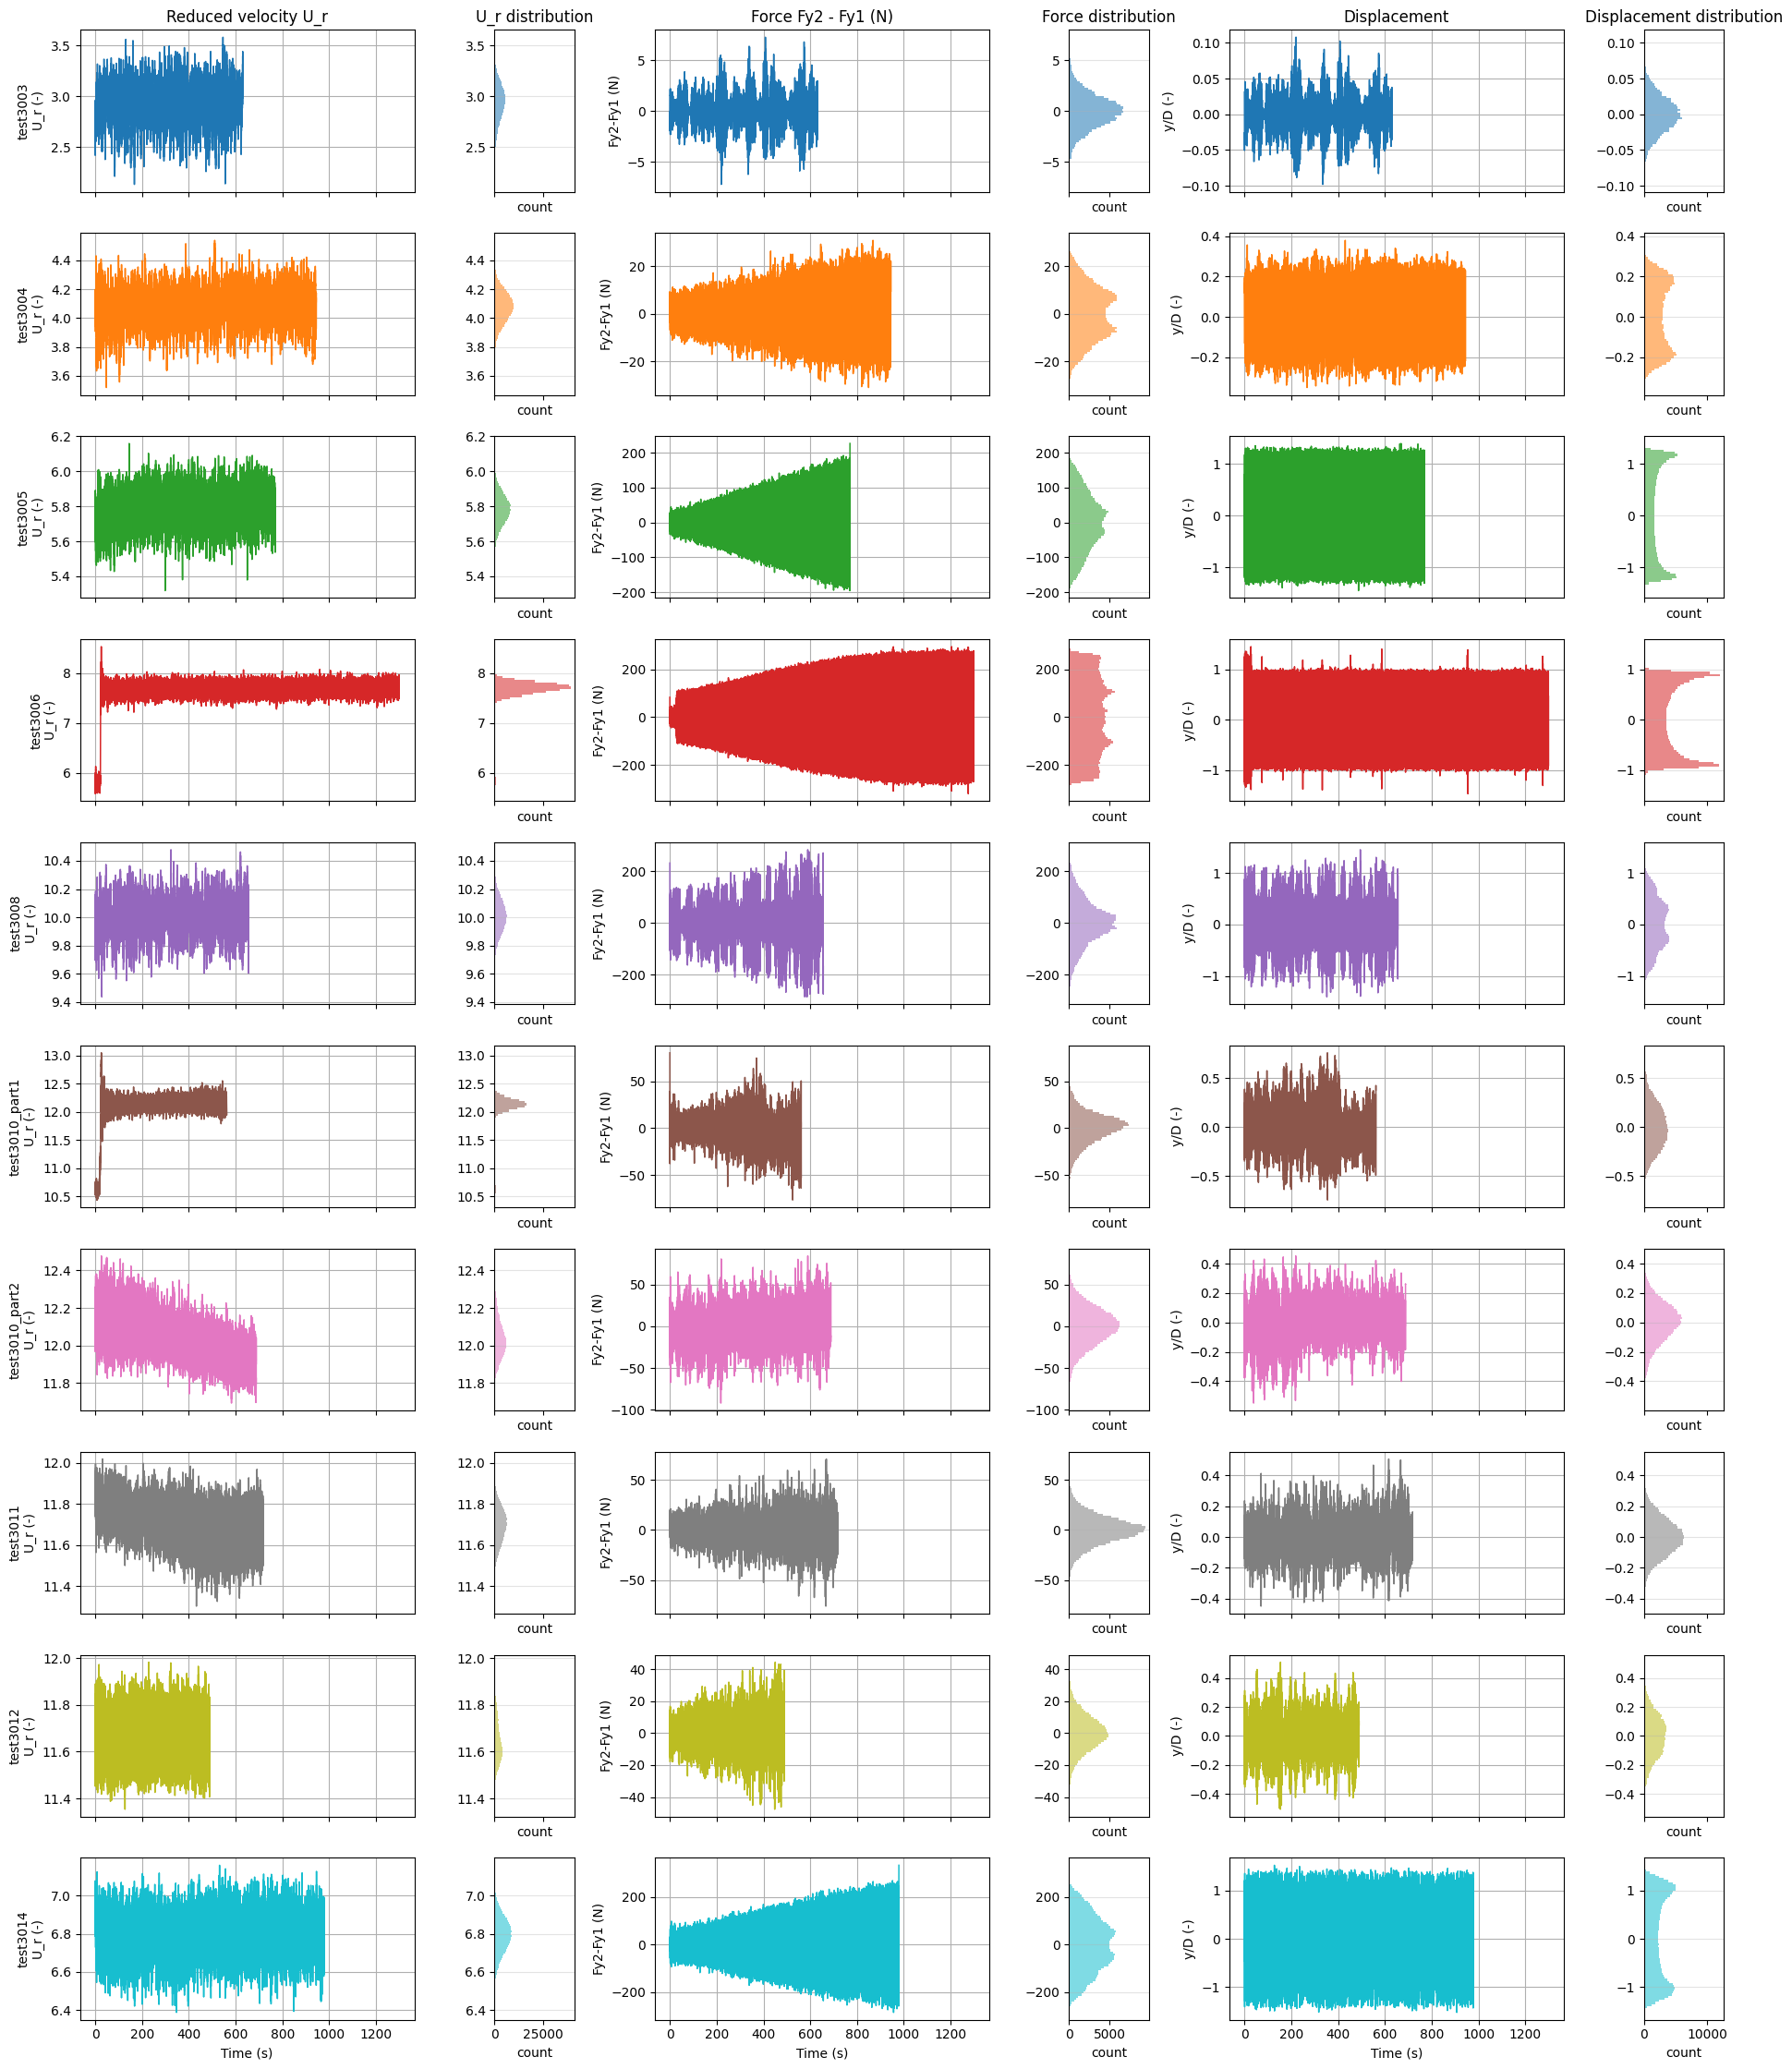

In [19]:
# Figure 2: U_r, Fy2-Fy1 and displacement with right-side rotated histograms
TS_HIST_BINS = 70
TS_HIST_ALPHA = 0.55
TS_HIST_LINEWIDTH = 1.1
TS_HIST_FIG_W = 19
TS_HIST_ROW_H = 2.25
USE_NORMALIZED_DISPLACEMENT = True  # True -> y/D (mean removed), False -> raw displacement y (m)

n_rows = len(entries)
fig2, axes2 = plt.subplots(
    n_rows,
    6,
    figsize=(TS_HIST_FIG_W, max(TS_HIST_ROW_H * n_rows, 2.8)),
    sharex='col',
    gridspec_kw={'width_ratios': [4.8, 1.15, 4.8, 1.15, 4.8, 1.15]},
)
axes2 = np.atleast_2d(axes2)

titles = [
    'Reduced velocity U_r', 'U_r distribution',
    'Force Fy2 - Fy1 (N)', 'Force distribution',
    'Displacement', 'Displacement distribution',
]
for j, title in enumerate(titles):
    axes2[0, j].set_title(title)

for i, entry in enumerate(entries):
    color = colors[i % len(colors)]
    label = str(entry['label'])

    t = np.asarray(entry['time_plot'], dtype=float)
    ur = np.asarray(entry['ur_inst'], dtype=float)
    fy = np.asarray(entry.get('cfy_force', entry['cfy']), dtype=float)
    if USE_NORMALIZED_DISPLACEMENT:
        disp = np.asarray(entry['y_nd'], dtype=float)
        disp_ylabel = 'y/D (-)'
    else:
        disp = np.asarray(entry['y'], dtype=float)
        disp_ylabel = 'y (m)'

    signals = [
        (ur, 'U_r (-)'),
        (fy, 'Fy2-Fy1 (N)'),
        (disp, disp_ylabel),
    ]

    for k, (vals, ylab) in enumerate(signals):
        ax_ts = axes2[i, 2 * k]
        ax_hist = axes2[i, 2 * k + 1]

        finite = np.isfinite(t) & np.isfinite(vals)
        t_plot = t[finite]
        v_plot = vals[finite]
        if t_plot.size == 0:
            continue

        ax_ts.plot(t_plot, v_plot, color=color, linewidth=TS_HIST_LINEWIDTH)
        ax_ts.grid(True)
        if k == 0:
            ax_ts.set_ylabel(f"{label}\n{ylab}")
        else:
            ax_ts.set_ylabel(ylab)

        ax_hist.hist(
            v_plot,
            bins=int(TS_HIST_BINS),
            orientation='horizontal',
            color=color,
            alpha=TS_HIST_ALPHA,
            edgecolor='none',
        )
        ax_hist.set_ylim(ax_ts.get_ylim())
        ax_hist.grid(True, axis='y', alpha=0.35)
        ax_hist.set_xlabel('count')

for j in [0, 2, 4]:
    axes2[-1, j].set_xlabel('Time (s)')
for j in [1, 3, 5]:
    axes2[-1, j].set_xlabel('count')

fig2.tight_layout()
plt.show()



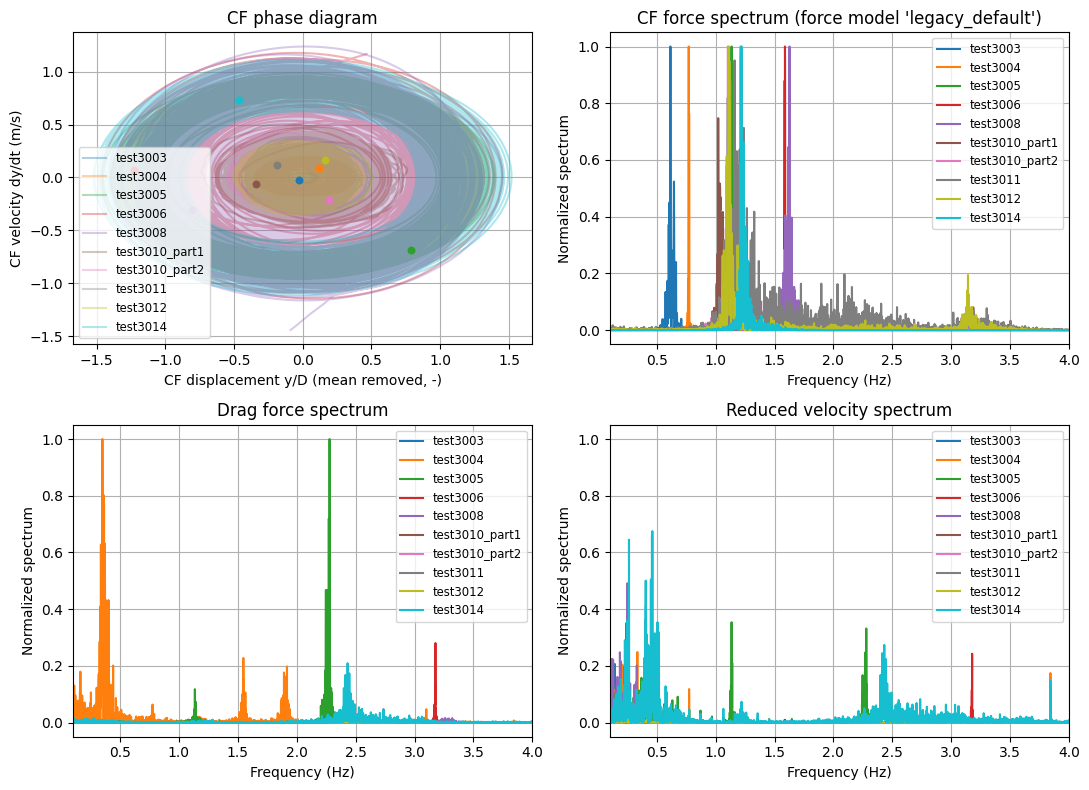

In [20]:
# Figure 3: phase + spectra overlay
FIG3_SIZE = (11, 8)
SPECTRUM_XMIN = 0.1
SPECTRUM_XMAX = float(analysis.SPECTRUM_PLOT_MAX_HZ)

fig3, axes3 = plt.subplots(2, 2, figsize=FIG3_SIZE)
ax_phase = axes3[0, 0]
for i, entry in enumerate(entries):
    color = colors[i % len(colors)]
    label = str(entry['label'])
    y_nd = np.asarray(entry['y_nd'])
    yvel = np.asarray(entry['yvel'])
    ax_phase.plot(y_nd, yvel, color=color, alpha=0.35, label=label)
    ax_phase.scatter(y_nd[0], yvel[0], color=color, s=22, zorder=3)
ax_phase.grid(True)
ax_phase.set_xlabel('CF displacement y/D (mean removed, -)')
ax_phase.set_ylabel('CF velocity dy/dt (m/s)')
ax_phase.set_title('CF phase diagram')
analysis._add_legends([ax_phase])

ax_fy = axes3[0, 1]
ax_fd = axes3[1, 0]
ax_ur = axes3[1, 1]
for i, entry in enumerate(entries):
    color = colors[i % len(colors)]
    label = str(entry['label'])
    f_cfy, sp_cfy, n_cfy = entry['sp_cfy']
    f_cdrag, sp_cdrag, n_cdrag = entry['sp_cdrag']
    f_ur, sp_ur, n_ur = entry['sp_ur']
    ax_fy.plot(np.asarray(f_cfy)[: int(n_cfy)], np.asarray(sp_cfy)[: int(n_cfy)], color=color, label=label)
    ax_fd.plot(np.asarray(f_cdrag)[: int(n_cdrag)], np.asarray(sp_cdrag)[: int(n_cdrag)], color=color, label=label)
    ax_ur.plot(np.asarray(f_ur)[: int(n_ur)], np.asarray(sp_ur)[: int(n_ur)], color=color, label=label)
ax_fy.set_xlim(SPECTRUM_XMIN, SPECTRUM_XMAX)
ax_fy.grid(True)
ax_fy.set_xlabel('Frequency (Hz)')
ax_fy.set_ylabel('Normalized spectrum' if analysis.NORMALIZE_SPECTRA else 'Spectrum')
ax_fy.set_title(f"{analysis._cf_name()} spectrum ({analysis._cf_force_mode_label()})")
ax_fd.set_xlim(SPECTRUM_XMIN, SPECTRUM_XMAX)
ax_fd.grid(True)
ax_fd.set_xlabel('Frequency (Hz)')
ax_fd.set_ylabel('Normalized spectrum' if analysis.NORMALIZE_SPECTRA else 'Spectrum')
ax_fd.set_title(f"{analysis._drag_name()} spectrum")
ax_ur.set_xlim(SPECTRUM_XMIN, SPECTRUM_XMAX)
ax_ur.grid(True)
ax_ur.set_xlabel('Frequency (Hz)')
ax_ur.set_ylabel('Normalized spectrum' if analysis.NORMALIZE_SPECTRA else 'Spectrum')
ax_ur.set_title('Reduced velocity spectrum')
analysis._add_legends([ax_fy, ax_fd, ax_ur])
fig3.tight_layout()
plt.show()

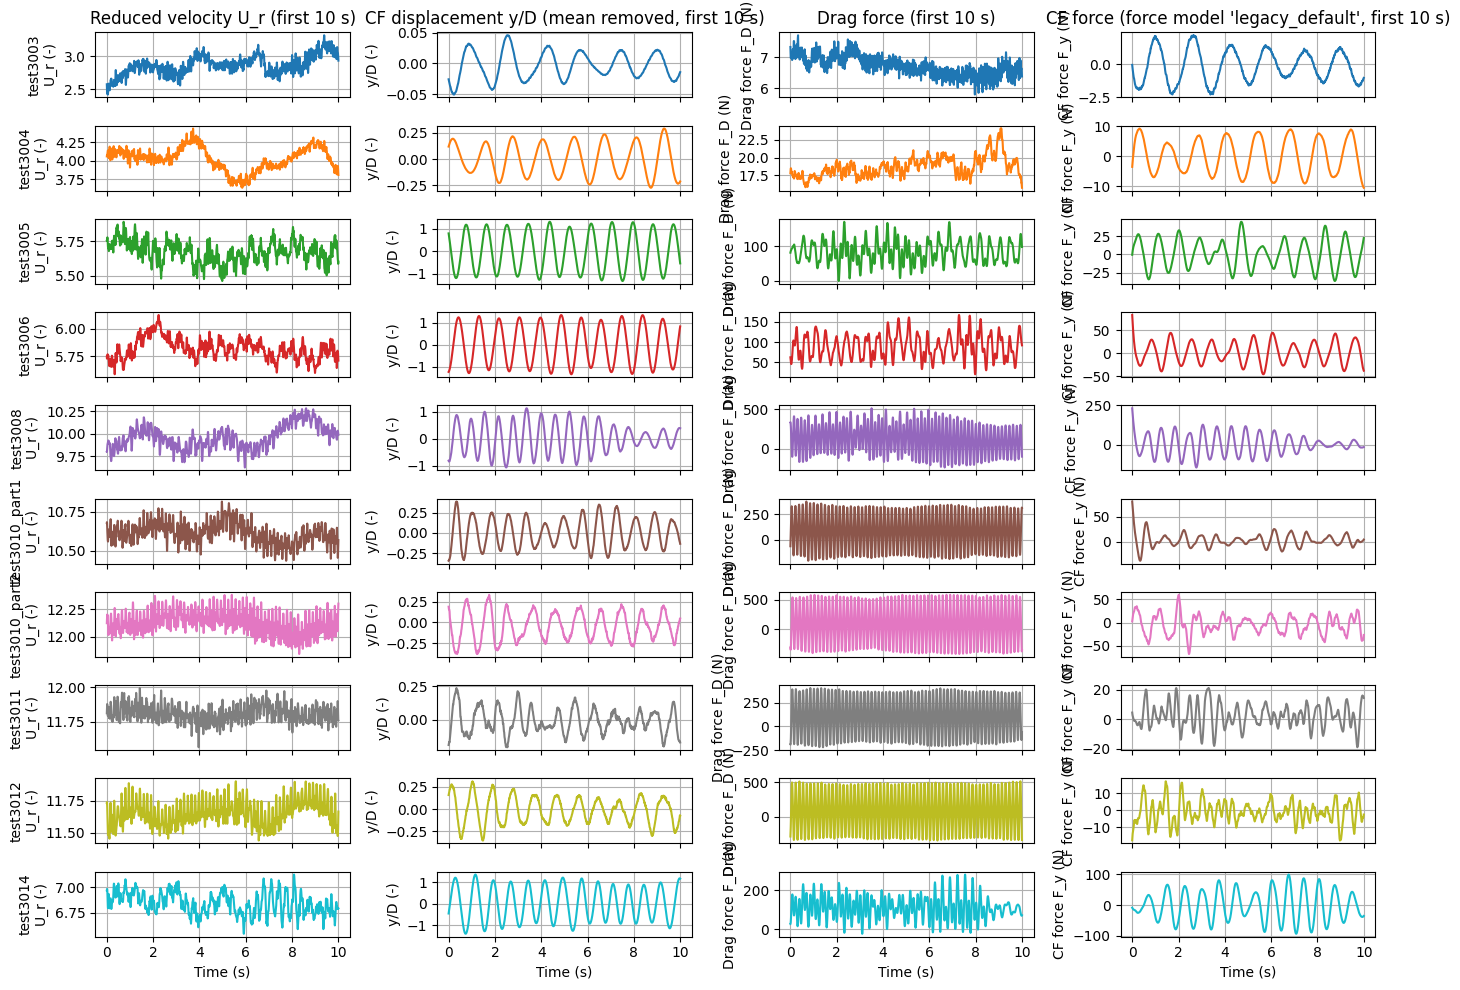

In [21]:
# Figure 4: first N seconds
FIG4_WIDTH = 14
FIG4_ROW_HEIGHT = 1.0
FIG4_MIN_HEIGHT = 2.0
FIG4_FIRST_WINDOW_SECONDS = float(analysis.FIRST_WINDOW_SECONDS)

fig4, axes4 = plt.subplots(
    n_rows,
    4,
    figsize=(FIG4_WIDTH, max(FIG4_ROW_HEIGHT * n_rows, FIG4_MIN_HEIGHT)),
    sharex='col',
)
axes4 = np.atleast_2d(axes4)
col_titles = [
    f"Reduced velocity U_r (first {FIG4_FIRST_WINDOW_SECONDS:g} s)",
    f"CF displacement y/D (mean removed, first {FIG4_FIRST_WINDOW_SECONDS:g} s)",
    f"{analysis._drag_name()} (first {FIG4_FIRST_WINDOW_SECONDS:g} s)",
    f"{analysis._cf_name()} ({analysis._cf_force_mode_label()}, first {FIG4_FIRST_WINDOW_SECONDS:g} s)",
]
for j, title in enumerate(col_titles):
    axes4[0, j].set_title(title)

for i, entry in enumerate(entries):
    color = colors[i % len(colors)]
    label = str(entry['label'])
    t_full = np.asarray(entry['time_plot'])
    mask = t_full <= FIG4_FIRST_WINDOW_SECONDS
    ax_ur, ax_y, ax_cd, ax_cf = axes4[i, 0], axes4[i, 1], axes4[i, 2], axes4[i, 3]
    if np.any(mask):
        t = t_full[mask]
        ax_ur.plot(t, np.asarray(entry['ur_inst'])[mask], color=color)
        ax_y.plot(t, np.asarray(entry['y_nd'])[mask], color=color)
        ax_cd.plot(t, np.asarray(entry['cdrag'])[mask], color=color)
        ax_cf.plot(t, np.asarray(entry['cfy'])[mask], color=color)
    for ax in (ax_ur, ax_y, ax_cd, ax_cf):
        ax.grid(True)
    ax_ur.set_ylabel(f"{label}\nU_r (-)")
    ax_y.set_ylabel('y/D (-)')
    ax_cd.set_ylabel(analysis._drag_label())
    ax_cf.set_ylabel(analysis._cf_label())

for j in range(4):
    axes4[-1, j].set_xlabel('Time (s)')
fig4.tight_layout()
plt.show()

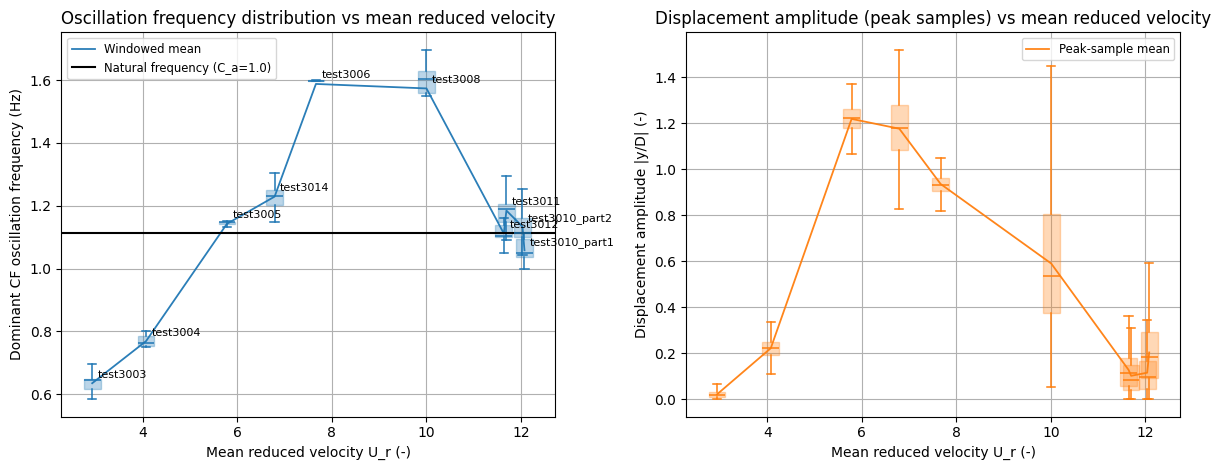

In [22]:
# Figure 5: summary trends vs mean reduced velocity (box plots per U_r)
FIG5_SIZE = (12, 4.8)
REF_CA_FOR_FN_LINE = float(analysis.REF_CA_FOR_FN_LINE)
ANNOTATE_POINTS = True

# Frequency sampling settings (time-window control).
FREQ_WINDOW_SECONDS = 20.0
FREQ_STEP_SECONDS = 4.0
MIN_WINDOW_POINTS = 64

# Box-plot styling.
BOXPLOT_SHOW_FLIERS = False
BOXPLOT_FACE_ALPHA = 0.30
BOXPLOT_WIDTH_MODE = 'auto'    # 'auto' or numeric width in U_r units
BOXPLOT_MIN_WIDTH = 0.20
BOXPLOT_MAX_WIDTH = 0.70
BOXPLOT_WIDTH_SCALE = 0.35
PLOT_MEAN_LINE = True

entries_sorted = sorted(entries, key=lambda e: float(e['summary']['ur']))
labels_sorted = [str(e['label']) for e in entries_sorted]

fig5, axes5 = plt.subplots(1, 2, figsize=FIG5_SIZE)
ax_f, ax_a = axes5

m_added_ref = REF_CA_FOR_FN_LINE * 0.25 * np.pi * analysis.RUO * analysis.D * analysis.D * analysis.L
f_n_ref = (1.0 / (2.0 * np.pi)) * np.sqrt(analysis.K / (analysis.M + m_added_ref))


def _window_length_from_seconds(n: int, fs: float, window_seconds: float) -> int:
    if np.isfinite(fs) and fs > 0.0 and np.isfinite(window_seconds) and window_seconds > 0.0:
        win_len = int(round(float(window_seconds) * float(fs)))
    else:
        win_len = n
    return int(max(int(MIN_WINDOW_POINTS), min(n, win_len)))


def _step_points_from_seconds(fs: float, step_seconds: float, win_len: int) -> int:
    if np.isfinite(fs) and fs > 0.0 and np.isfinite(step_seconds) and step_seconds > 0.0:
        step = int(round(float(step_seconds) * float(fs)))
    else:
        step = max(1, win_len // 2)
    return int(max(1, step))


def _window_starts(n: int, win_len: int, step_points: int) -> np.ndarray:
    if n <= win_len:
        return np.array([0], dtype=int)

    starts = np.arange(0, n - win_len + 1, int(max(1, step_points)), dtype=int)
    if starts.size == 0:
        starts = np.array([0], dtype=int)
    tail = n - win_len
    if int(starts[-1]) != int(tail):
        starts = np.append(starts, int(tail))
    return np.unique(starts)


def _box_width(positions: np.ndarray) -> float:
    if np.isscalar(BOXPLOT_WIDTH_MODE) and str(BOXPLOT_WIDTH_MODE).lower() != 'auto':
        return float(BOXPLOT_WIDTH_MODE)
    x = np.asarray(positions, dtype=float)
    if x.size < 2:
        return float(BOXPLOT_MIN_WIDTH)
    diffs = np.diff(np.sort(np.unique(x)))
    diffs = diffs[np.isfinite(diffs) & (diffs > 0)]
    if diffs.size == 0:
        return float(BOXPLOT_MIN_WIDTH)
    w = float(BOXPLOT_WIDTH_SCALE) * float(np.median(diffs))
    return float(np.clip(w, BOXPLOT_MIN_WIDTH, BOXPLOT_MAX_WIDTH))


def _dominant_freq_subbin(freq: np.ndarray, spec: np.ndarray, *, fmin: float, fmax: float) -> float:
    f = np.asarray(freq, dtype=float).reshape(-1)
    s = np.nan_to_num(np.asarray(spec, dtype=float).reshape(-1), nan=0.0, posinf=0.0, neginf=0.0)

    band = (f >= float(fmin)) & (f <= float(fmax))
    if np.any(band):
        fb = f[band]
        sb = s[band]
    else:
        pos = f > 0.0
        if not np.any(pos):
            return float('nan')
        fb = f[pos]
        sb = s[pos]

    if fb.size == 0:
        return float('nan')

    k = int(np.argmax(sb))
    f_peak = float(fb[k])

    # Parabolic refinement around the spectral peak to reduce FFT-bin locking.
    if 0 < k < (fb.size - 1):
        y1 = float(sb[k - 1])
        y2 = float(sb[k])
        y3 = float(sb[k + 1])
        denom = (y1 - 2.0 * y2 + y3)
        if np.isfinite(denom) and abs(denom) > 1e-20:
            delta = 0.5 * (y1 - y3) / denom
            delta = float(np.clip(delta, -1.0, 1.0))
            step_l = float(fb[k] - fb[k - 1])
            step_r = float(fb[k + 1] - fb[k])
            step = 0.5 * (step_l + step_r)
            if np.isfinite(step) and step > 0.0:
                f_peak = float(fb[k] + delta * step)

    return f_peak


def _amplitude_samples_from_peaks(y_nd: np.ndarray) -> np.ndarray:
    y = np.asarray(y_nd, dtype=float).reshape(-1)
    finite = np.isfinite(y)
    y = y[finite]
    if y.size == 0:
        return np.asarray([], dtype=float)

    y_centered = y - float(np.mean(y))
    peaks, _ = analysis.find_peaks(y_centered)
    troughs, _ = analysis.find_peaks(-y_centered)

    amp_samples = np.concatenate([np.abs(y_centered[peaks]), np.abs(y_centered[troughs])])
    if amp_samples.size < 4:
        amp_samples = np.abs(y_centered)

    amp_samples = amp_samples[np.isfinite(amp_samples)]
    return np.asarray(amp_samples, dtype=float)


def _case_trend_samples(entry: dict):
    summary = entry.get('summary', {})
    y_raw = np.asarray(entry.get('y', []), dtype=float)
    y_nd = np.asarray(entry.get('y_nd', []), dtype=float)
    fs = float(summary.get('fs', np.nan))

    n = int(min(y_raw.size, y_nd.size))
    if n < 16:
        f_fb = float(summary.get('ydomfreq', np.nan))
        a_fb = float(summary.get('amp_mean', np.nan))
        f_arr = np.asarray([f_fb], dtype=float) if np.isfinite(f_fb) else np.asarray([], dtype=float)
        a_arr = np.asarray([a_fb], dtype=float) if np.isfinite(a_fb) else np.asarray([], dtype=float)
        return f_arr, a_arr

    y_raw = y_raw[:n]
    y_nd = y_nd[:n]

    # Frequency distribution: windowed dominant-frequency samples.
    win_len_f = _window_length_from_seconds(n, fs=fs, window_seconds=FREQ_WINDOW_SECONDS)
    step_f = _step_points_from_seconds(fs=fs, step_seconds=FREQ_STEP_SECONDS, win_len=win_len_f)
    starts_f = _window_starts(n, win_len_f, step_f)

    freq_samples = []
    for s in starts_f:
        yw = np.asarray(y_raw[s:s + win_len_f], dtype=float)
        try:
            spec_w, freq_w, _ = analysis._spec(yw, fs)
            if analysis.NORMALIZE_SPECTRA:
                spec_w = analysis._normalize_spectrum(spec_w, eps=analysis.SPECTRUM_NORM_EPS)
            f_dom = _dominant_freq_subbin(
                np.asarray(freq_w, dtype=float),
                np.asarray(spec_w, dtype=float),
                fmin=float(analysis.DOM_FREQ_MIN_HZ),
                fmax=float(analysis.DOM_FREQ_MAX_HZ),
            )
        except Exception:
            f_dom = np.nan
        if np.isfinite(f_dom):
            freq_samples.append(float(f_dom))

    # Amplitude distribution: direct peak/trough samples over full case.
    amp_samples = _amplitude_samples_from_peaks(y_nd)

    if not freq_samples:
        f_fb = float(summary.get('ydomfreq', np.nan))
        if np.isfinite(f_fb):
            freq_samples = [f_fb]
    if amp_samples.size == 0:
        a_fb = float(summary.get('amp_mean', np.nan))
        if np.isfinite(a_fb):
            amp_samples = np.asarray([a_fb], dtype=float)

    return np.asarray(freq_samples, dtype=float), np.asarray(amp_samples, dtype=float)


ur_cases = []
labels_cases = []
freq_boxes = []
amp_boxes = []
freq_mean = []
amp_mean = []

for entry, label in zip(entries_sorted, labels_sorted):
    ur_val = float(entry.get('summary', {}).get('ur', np.nan))
    if not np.isfinite(ur_val):
        continue

    f_samp, a_samp = _case_trend_samples(entry)
    if f_samp.size == 0 or a_samp.size == 0:
        continue

    ur_cases.append(ur_val)
    labels_cases.append(label)
    freq_boxes.append(f_samp)
    amp_boxes.append(a_samp)
    freq_mean.append(float(np.nanmean(f_samp)))
    amp_mean.append(float(np.nanmean(a_samp)))

if ur_cases:
    ur_cases = np.asarray(ur_cases, dtype=float)
    freq_mean = np.asarray(freq_mean, dtype=float)
    amp_mean = np.asarray(amp_mean, dtype=float)

    order = np.argsort(ur_cases)
    ur_cases = ur_cases[order]
    labels_cases = [labels_cases[idx] for idx in order]
    freq_boxes = [freq_boxes[idx] for idx in order]
    amp_boxes = [amp_boxes[idx] for idx in order]
    freq_mean = freq_mean[order]
    amp_mean = amp_mean[order]

    width = _box_width(ur_cases)

    bp_f = ax_f.boxplot(
        freq_boxes,
        positions=ur_cases,
        widths=width,
        patch_artist=True,
        showfliers=bool(BOXPLOT_SHOW_FLIERS),
        manage_ticks=False,
    )
    for patch in bp_f['boxes']:
        patch.set_facecolor('tab:blue')
        patch.set_alpha(BOXPLOT_FACE_ALPHA)
        patch.set_edgecolor('tab:blue')
        patch.set_linewidth(1.0)
    for key in ('whiskers', 'caps', 'medians'):
        for artist in bp_f[key]:
            artist.set_color('tab:blue')
            artist.set_linewidth(1.1)

    bp_a = ax_a.boxplot(
        amp_boxes,
        positions=ur_cases,
        widths=width,
        patch_artist=True,
        showfliers=bool(BOXPLOT_SHOW_FLIERS),
        manage_ticks=False,
    )
    for patch in bp_a['boxes']:
        patch.set_facecolor('tab:orange')
        patch.set_alpha(BOXPLOT_FACE_ALPHA)
        patch.set_edgecolor('tab:orange')
        patch.set_linewidth(1.0)
    for key in ('whiskers', 'caps', 'medians'):
        for artist in bp_a[key]:
            artist.set_color('tab:orange')
            artist.set_linewidth(1.1)

    if PLOT_MEAN_LINE:
        ax_f.plot(ur_cases, freq_mean, color='tab:blue', linewidth=1.3, alpha=0.95, label='Windowed mean')

        ax_a.plot(ur_cases, amp_mean, color='tab:orange', linewidth=1.3, alpha=0.95, label='Peak-sample mean')

    if ANNOTATE_POINTS:
        for x, yv, name in zip(ur_cases, freq_mean, labels_cases):
            ax_f.annotate(name, (x, yv), textcoords='offset points', xytext=(4, 4), fontsize=8)

ax_f.axhline(
    f_n_ref,
    color='black',
    linewidth=1.5,
    linestyle='-',
    label=f"Natural frequency (C_a={REF_CA_FOR_FN_LINE:.1f})",
)
ax_f.grid(True)
ax_f.set_xlabel('Mean reduced velocity U_r (-)')
ax_f.set_ylabel('Dominant CF oscillation frequency (Hz)')
ax_f.set_title('Oscillation frequency distribution vs mean reduced velocity')
ax_f.legend(loc='best', fontsize='small')

ax_a.grid(True)
ax_a.set_xlabel('Mean reduced velocity U_r (-)')
ax_a.set_ylabel('Displacement amplitude |y/D| (-)')
ax_a.set_title('Displacement amplitude (peak samples) vs mean reduced velocity')
if PLOT_MEAN_LINE:
    ax_a.legend(loc='best', fontsize='small')

fig5.tight_layout()
plt.show()


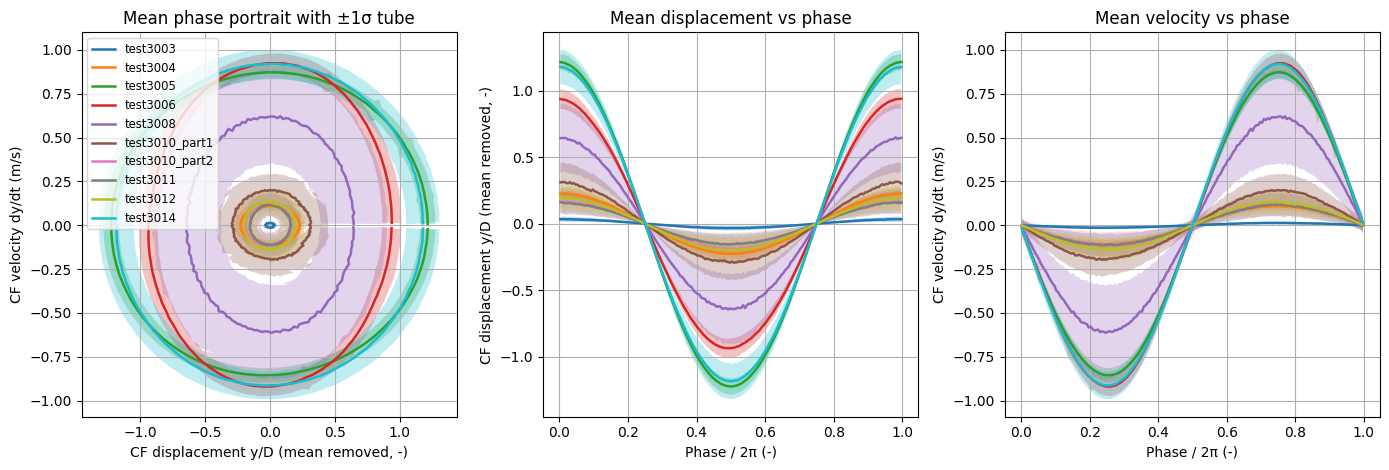

In [23]:
# Figure 6: phase-binned mean phase portrait
FIG6_SIZE = (14, 4.8)
PHASE_MEAN_BINS = int(analysis.PHASE_MEAN_BINS)
PHASE_MIN_SAMPLES_PER_BIN = int(analysis.PHASE_MIN_SAMPLES_PER_BIN)

fig6, axes6 = plt.subplots(1, 3, figsize=FIG6_SIZE)
ax_phase_mean, ax_y_phase, ax_v_phase = axes6

for i, entry in enumerate(entries):
    color = colors[i % len(colors)]
    label = str(entry['label'])
    try:
        phase_stats = analysis._phase_binned_phase_portrait(
            np.asarray(entry['y_nd']),
            np.asarray(entry['yvel']),
            n_bins=PHASE_MEAN_BINS,
            min_samples_per_bin=PHASE_MIN_SAMPLES_PER_BIN,
        )
    except ValueError as exc:
        warnings.warn(f"{label}: skipped mean phase plot ({exc})")
        continue

    theta = np.asarray(phase_stats['theta'], dtype=float)
    mean_y = np.asarray(phase_stats['mean_y'], dtype=float)
    mean_v = np.asarray(phase_stats['mean_v'], dtype=float)
    std_y = np.asarray(phase_stats['std_y'], dtype=float)
    std_v = np.asarray(phase_stats['std_v'], dtype=float)
    upper_y = np.asarray(phase_stats['upper_y'], dtype=float)
    upper_v = np.asarray(phase_stats['upper_v'], dtype=float)
    lower_y = np.asarray(phase_stats['lower_y'], dtype=float)
    lower_v = np.asarray(phase_stats['lower_v'], dtype=float)

    poly_x = np.concatenate([upper_y, lower_y[::-1]])
    poly_y = np.concatenate([upper_v, lower_v[::-1]])
    ax_phase_mean.fill(poly_x, poly_y, color=color, alpha=0.28, edgecolor='none')
    ax_phase_mean.plot(mean_y, mean_v, color=color, linewidth=1.8, label=label)

    phase_norm = theta / (2.0 * np.pi)
    ax_y_phase.fill_between(phase_norm, mean_y - std_y, mean_y + std_y, color=color, alpha=0.28, edgecolor='none')
    ax_y_phase.plot(phase_norm, mean_y, color=color, linewidth=1.8, label=label)

    ax_v_phase.fill_between(phase_norm, mean_v - std_v, mean_v + std_v, color=color, alpha=0.28, edgecolor='none')
    ax_v_phase.plot(phase_norm, mean_v, color=color, linewidth=1.8, label=label)

ax_phase_mean.grid(True)
ax_phase_mean.set_xlabel('CF displacement y/D (mean removed, -)')
ax_phase_mean.set_ylabel('CF velocity dy/dt (m/s)')
ax_phase_mean.set_title('Mean phase portrait with ±1σ tube')
ax_y_phase.grid(True)
ax_y_phase.set_xlabel('Phase / 2π (-)')
ax_y_phase.set_ylabel('CF displacement y/D (mean removed, -)')
ax_y_phase.set_title('Mean displacement vs phase')
ax_v_phase.grid(True)
ax_v_phase.set_xlabel('Phase / 2π (-)')
ax_v_phase.set_ylabel('CF velocity dy/dt (m/s)')
ax_v_phase.set_title('Mean velocity vs phase')
analysis._add_legends([ax_phase_mean])
fig6.tight_layout()
plt.show()

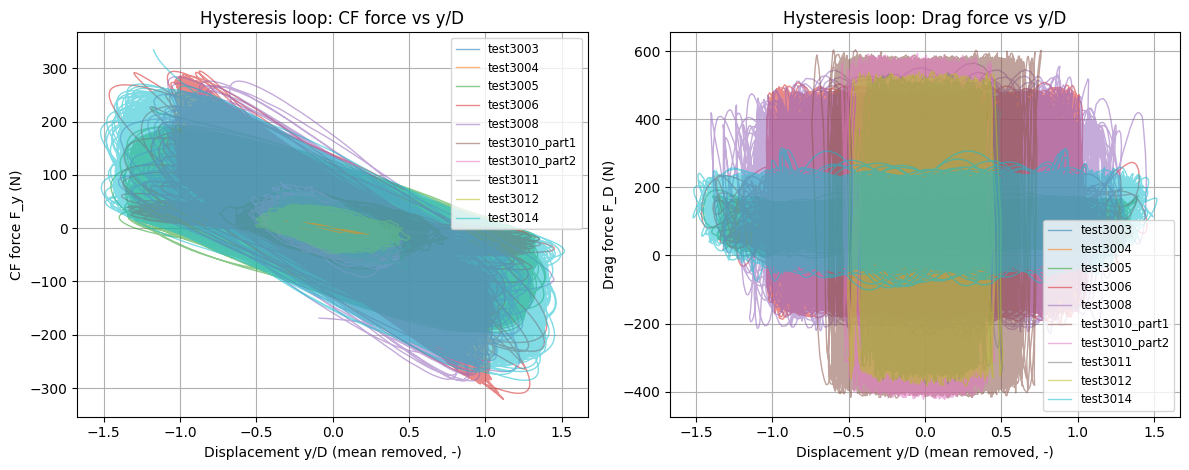

In [24]:
# Figure 7: hysteresis loops
FIG7_SIZE = (12, 4.8)
HYSTERESIS_ALPHA = 0.55
HYSTERESIS_LINEWIDTH = 1.0

fig7, (ax_h_cf, ax_h_cd) = plt.subplots(1, 2, figsize=FIG7_SIZE)
for i, entry in enumerate(entries):
    color = colors[i % len(colors)]
    label = str(entry['label'])
    y_nd = np.asarray(entry['y_nd'], dtype=float)
    cfy = np.asarray(entry['cfy'], dtype=float)
    cdrag = np.asarray(entry['cdrag'], dtype=float)
    mask_cf = np.isfinite(y_nd) & np.isfinite(cfy)
    mask_cd = np.isfinite(y_nd) & np.isfinite(cdrag)
    ax_h_cf.plot(y_nd[mask_cf], cfy[mask_cf], color=color, alpha=HYSTERESIS_ALPHA, linewidth=HYSTERESIS_LINEWIDTH, label=label)
    ax_h_cd.plot(y_nd[mask_cd], cdrag[mask_cd], color=color, alpha=HYSTERESIS_ALPHA, linewidth=HYSTERESIS_LINEWIDTH, label=label)
ax_h_cf.grid(True)
ax_h_cf.set_xlabel('Displacement y/D (mean removed, -)')
ax_h_cf.set_ylabel(analysis._cf_label())
ax_h_cf.set_title(f"Hysteresis loop: {analysis._cf_name()} vs y/D")
ax_h_cd.grid(True)
ax_h_cd.set_xlabel('Displacement y/D (mean removed, -)')
ax_h_cd.set_ylabel(analysis._drag_label())
ax_h_cd.set_title(f"Hysteresis loop: {analysis._drag_name()} vs y/D")
analysis._add_legends([ax_h_cf, ax_h_cd])
fig7.tight_layout()
plt.show()

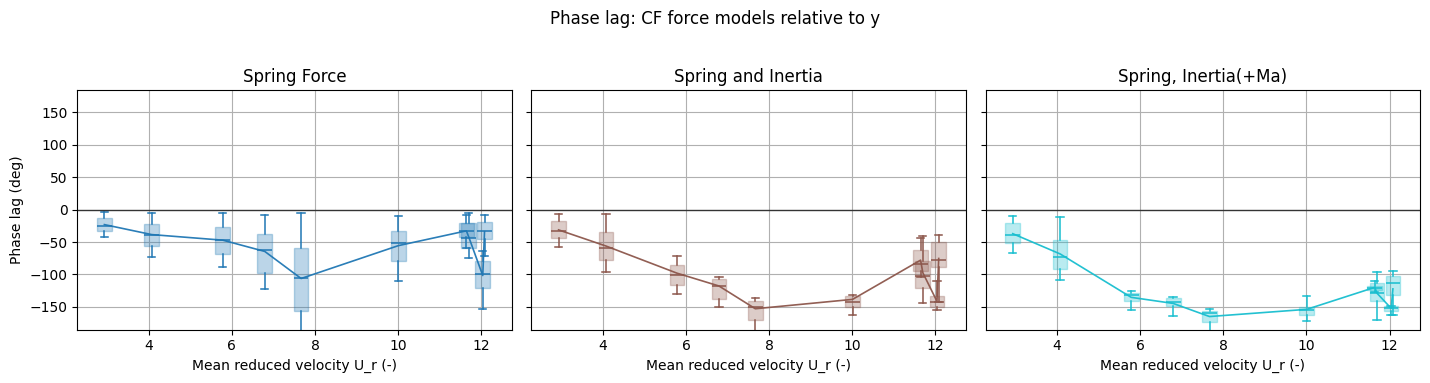

In [25]:
# Figure 8: phase lag vs reduced velocity (box plots per U_r and model)
PHASE_YLIM = (-185.0, 185.0)
# Empty => plot all available CF force models.
PHASE_MODELS_TO_PLOT = []
ANNOTATE_POINTS = False
FIG8_MODEL_NCOLS = 3
FIG8_MODEL_SUBPLOT_SIZE = (4.8, 3.8)  # (width, height) per subplot

# Phase sampling settings (distribution per case for box plots).
PHASE_SAMPLE_WINDOWS = 10          # number of windows per case used for phase samples
PHASE_SAMPLE_MIN_CYCLES = 2.0      # minimum cycles per window (based on ydomfreq)
PHASE_SAMPLE_MIN_POINTS = 256      # hard floor on points per window

# Box-plot styling.
BOXPLOT_SHOW_FLIERS = False
BOXPLOT_FACE_ALPHA = 0.30
BOXPLOT_WIDTH_MODE = 'auto'        # 'auto' or numeric width in U_r units
BOXPLOT_MIN_WIDTH = 0.20
BOXPLOT_MAX_WIDTH = 0.70
BOXPLOT_WIDTH_SCALE = 0.35         # used when width mode is 'auto'
PLOT_PHASE_MEAN_LINE = True        # overlay circular-mean line across U_r

entries_sorted = sorted(entries, key=lambda e: float(e['summary']['ur']))
labels_sorted = [str(e['label']) for e in entries_sorted]

# Resolve CF models to plot.
all_model_names = []
for entry in entries_sorted:
    for name in entry.get('cfy_model_names', []):
        if name not in all_model_names:
            all_model_names.append(name)
if not all_model_names:
    all_model_names = ['default']

if PHASE_MODELS_TO_PLOT:
    phase_models = [str(v) for v in PHASE_MODELS_TO_PLOT]
    missing = [v for v in phase_models if v not in all_model_names]
    if missing:
        raise ValueError(f"Unknown model(s) in PHASE_MODELS_TO_PLOT: {missing}. Available: {all_model_names}")
else:
    phase_models = list(all_model_names)

n_models = len(phase_models)
ncols = max(1, int(FIG8_MODEL_NCOLS))
nrows = int(np.ceil(n_models / ncols))
fig8, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(FIG8_MODEL_SUBPLOT_SIZE[0] * ncols, FIG8_MODEL_SUBPLOT_SIZE[1] * nrows),
    sharex=True,
    sharey=True,
)
axes_arr = np.atleast_1d(axes).reshape(-1)
model_colors = plt.cm.tab10(np.linspace(0.0, 1.0, max(n_models, 2)))


def _phase_samples_deg(y_signal: np.ndarray, f_signal: np.ndarray, fs: float, target_hz: float) -> np.ndarray:
    y = np.asarray(y_signal, dtype=float)
    f = np.asarray(f_signal, dtype=float)
    if y.size != f.size:
        return np.asarray([], dtype=float)

    finite = np.isfinite(y) & np.isfinite(f)
    y = y[finite]
    f = f[finite]
    n = int(y.size)
    if n < 32:
        return np.asarray([], dtype=float)

    if np.isfinite(target_hz) and target_hz > 0.0 and np.isfinite(fs) and fs > 0.0:
        samples_per_cycle = max(1, int(round(fs / target_hz)))
        win_len = max(int(round(PHASE_SAMPLE_MIN_CYCLES * samples_per_cycle)), int(PHASE_SAMPLE_MIN_POINTS))
    else:
        win_len = max(int(PHASE_SAMPLE_MIN_POINTS), n // max(2, int(PHASE_SAMPLE_WINDOWS)))

    win_len = min(win_len, n)
    if win_len < 16:
        return np.asarray([], dtype=float)

    if n <= win_len:
        starts = np.array([0], dtype=int)
    else:
        starts = np.linspace(0, n - win_len, max(1, int(PHASE_SAMPLE_WINDOWS))).astype(int)
        starts = np.unique(starts)

    vals = []
    for s in starts:
        yy = y[s:s + win_len]
        ff = f[s:s + win_len]
        try:
            ph = analysis._phase_lag_deg_at_frequency(yy, ff, fs=fs, target_hz=target_hz)
        except Exception:
            continue
        if np.isfinite(ph):
            vals.append(float(ph))

    return np.asarray(vals, dtype=float)


def _circular_mean_deg(samples_deg: np.ndarray) -> float:
    samples = np.asarray(samples_deg, dtype=float)
    samples = samples[np.isfinite(samples)]
    if samples.size == 0:
        return np.nan
    phi = np.deg2rad(samples)
    return float(np.rad2deg(np.arctan2(np.mean(np.sin(phi)), np.mean(np.cos(phi)))))


def _linearize_about_circular_mean(samples_deg: np.ndarray):
    samples = np.asarray(samples_deg, dtype=float)
    samples = samples[np.isfinite(samples)]
    if samples.size == 0:
        return np.asarray([], dtype=float), np.nan
    mean_deg = _circular_mean_deg(samples)
    phi = np.deg2rad(samples)
    mean_phi = np.deg2rad(mean_deg)
    delta = np.angle(np.exp(1j * (phi - mean_phi)))
    linear = mean_deg + np.rad2deg(delta)
    return linear, mean_deg


def _box_width(positions: np.ndarray) -> float:
    if np.isscalar(BOXPLOT_WIDTH_MODE) and str(BOXPLOT_WIDTH_MODE).lower() != 'auto':
        return float(BOXPLOT_WIDTH_MODE)
    x = np.asarray(positions, dtype=float)
    if x.size < 2:
        return float(BOXPLOT_MIN_WIDTH)
    diffs = np.diff(np.sort(np.unique(x)))
    diffs = diffs[np.isfinite(diffs) & (diffs > 0)]
    if diffs.size == 0:
        return float(BOXPLOT_MIN_WIDTH)
    w = float(BOXPLOT_WIDTH_SCALE) * float(np.median(diffs))
    return float(np.clip(w, BOXPLOT_MIN_WIDTH, BOXPLOT_MAX_WIDTH))


for i, model_name in enumerate(phase_models):
    ax = axes_arr[i]
    color = model_colors[i]

    ur_model = []
    labels_model = []
    phase_samples_for_boxes = []
    phase_mean_model = []

    for entry, label in zip(entries_sorted, labels_sorted):
        cfy_models = entry.get('cfy_models', {})
        if model_name not in cfy_models:
            continue

        ur_val = float(entry['summary'].get('ur', np.nan))
        fs = float(entry['summary'].get('fs', np.nan))
        ydomfreq = float(entry['summary'].get('ydomfreq', np.nan))
        y_nd = np.asarray(entry.get('y_nd', []), dtype=float)
        cfy_model = np.asarray(cfy_models[model_name], dtype=float)

        samples = _phase_samples_deg(y_nd, cfy_model, fs=fs, target_hz=ydomfreq)
        if samples.size == 0:
            fallback = float(entry.get('phase_cfy_by_model_deg', {}).get(model_name, np.nan))
            if np.isfinite(fallback):
                samples = np.asarray([fallback], dtype=float)

        linear_samples, mean_deg = _linearize_about_circular_mean(samples)
        if not (np.isfinite(ur_val) and np.isfinite(mean_deg) and linear_samples.size > 0):
            continue

        ur_model.append(ur_val)
        labels_model.append(label)
        phase_samples_for_boxes.append(linear_samples)
        phase_mean_model.append(mean_deg)

    if ur_model:
        ur_model = np.asarray(ur_model, dtype=float)
        phase_mean_model = np.asarray(phase_mean_model, dtype=float)

        order = np.argsort(ur_model)
        ur_model = ur_model[order]
        phase_mean_model = phase_mean_model[order]
        labels_model = [labels_model[idx] for idx in order]
        phase_samples_for_boxes = [phase_samples_for_boxes[idx] for idx in order]

        width = _box_width(ur_model)
        bp = ax.boxplot(
            phase_samples_for_boxes,
            positions=ur_model,
            widths=width,
            patch_artist=True,
            showfliers=bool(BOXPLOT_SHOW_FLIERS),
            manage_ticks=False,
        )

        for patch in bp['boxes']:
            patch.set_facecolor(color)
            patch.set_alpha(BOXPLOT_FACE_ALPHA)
            patch.set_edgecolor(color)
            patch.set_linewidth(1.0)
        for key in ('whiskers', 'caps', 'medians'):
            for artist in bp[key]:
                artist.set_color(color)
                artist.set_linewidth(1.1)

        if PLOT_PHASE_MEAN_LINE:
            ax.plot(ur_model, phase_mean_model, color=color, linewidth=1.2, alpha=0.95, zorder=3)

        if ANNOTATE_POINTS:
            for x, yv, name in zip(ur_model, phase_mean_model, labels_model):
                ax.annotate(name, (x, yv), textcoords='offset points', xytext=(4, 4), fontsize=8)

    ax.axhline(0.0, color='black', linewidth=1.0, alpha=0.7)
    ax.grid(True)
    ax.set_title(str(model_name))
    if PHASE_YLIM is not None:
        ax.set_ylim(*PHASE_YLIM)

# Hide unused axes if grid has extra cells.
for j in range(n_models, len(axes_arr)):
    axes_arr[j].set_visible(False)

# Shared labels.
for r in range(nrows):
    ax_left = axes_arr[r * ncols]
    if ax_left.get_visible():
        ax_left.set_ylabel('Phase lag (deg)')
for c in range(ncols):
    ax_bottom = axes_arr[(nrows - 1) * ncols + c]
    if ax_bottom.get_visible():
        ax_bottom.set_xlabel('Mean reduced velocity U_r (-)')

fig8.suptitle('Phase lag: CF force models relative to y', y=0.995)
fig8.tight_layout(rect=(0.0, 0.0, 1.0, 0.97))
plt.show()
